# Comparing attention methods on visual questions

**Input:** the two same-question GQA images used by the lens and knockout demos. **Model:** LLaVA-1.5-7B. **Tools:** Raw attention, Grad-CAM, ATTATTR, Rollout, TAM, Beyond Intuition-H/C, and generic relevance. Vision-classification methods are adapted to the language decoder and explicitly target a complete fixed answer.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


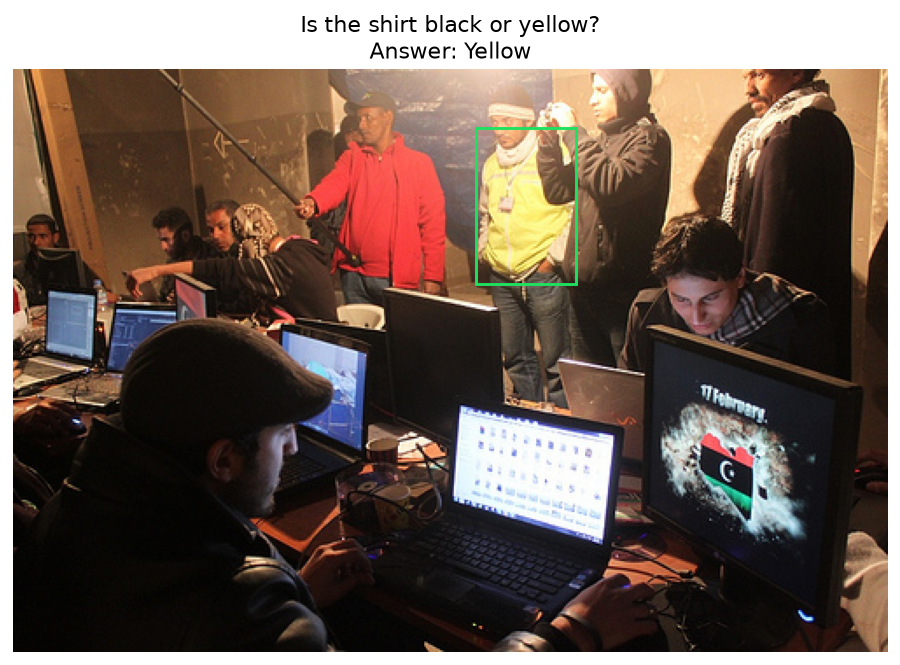

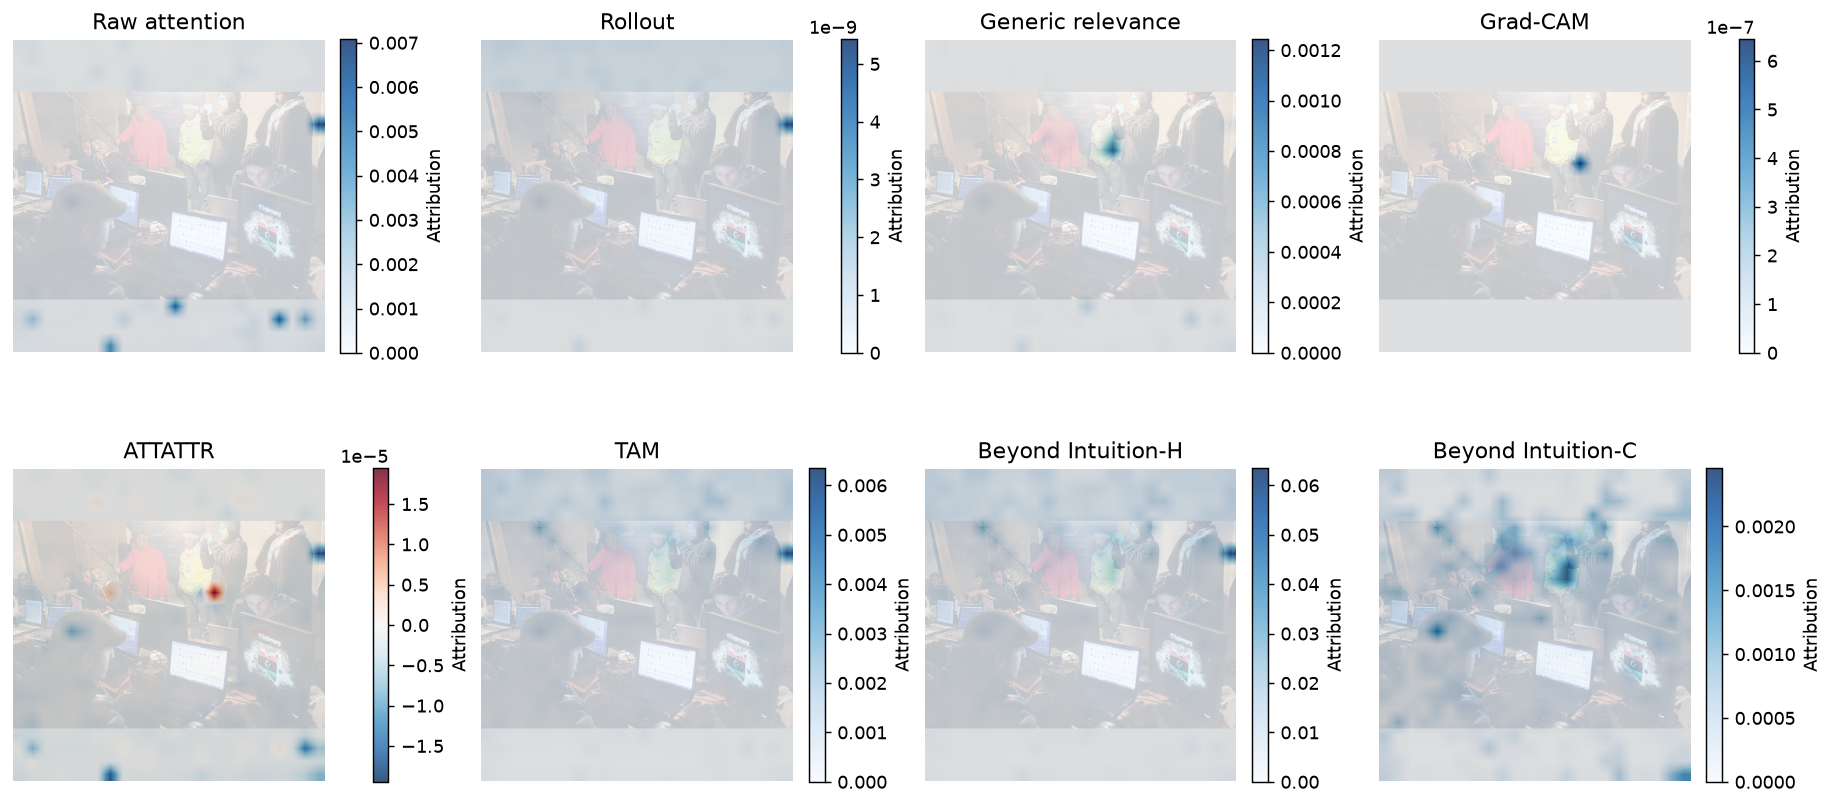

Native generated answer: Yellow
Fixed full-answer probability: 0.7532


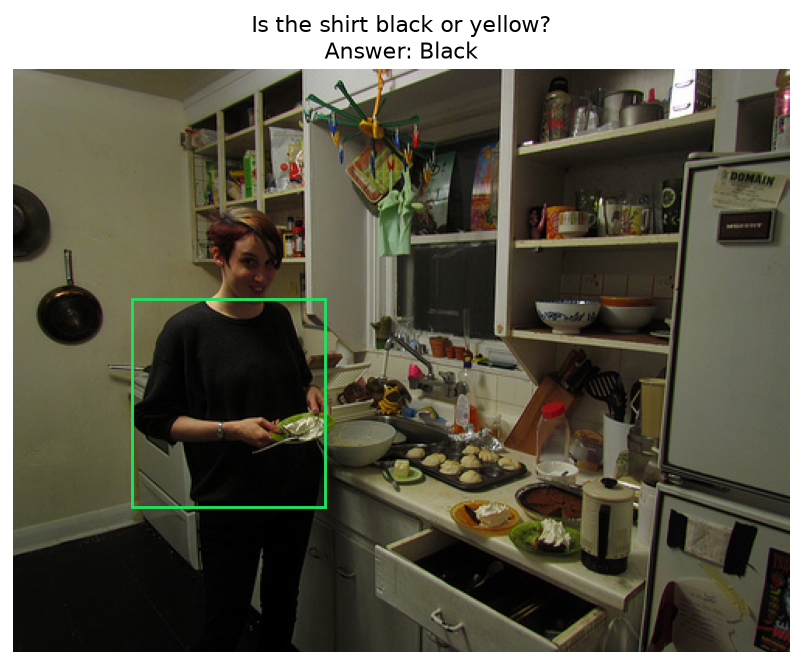

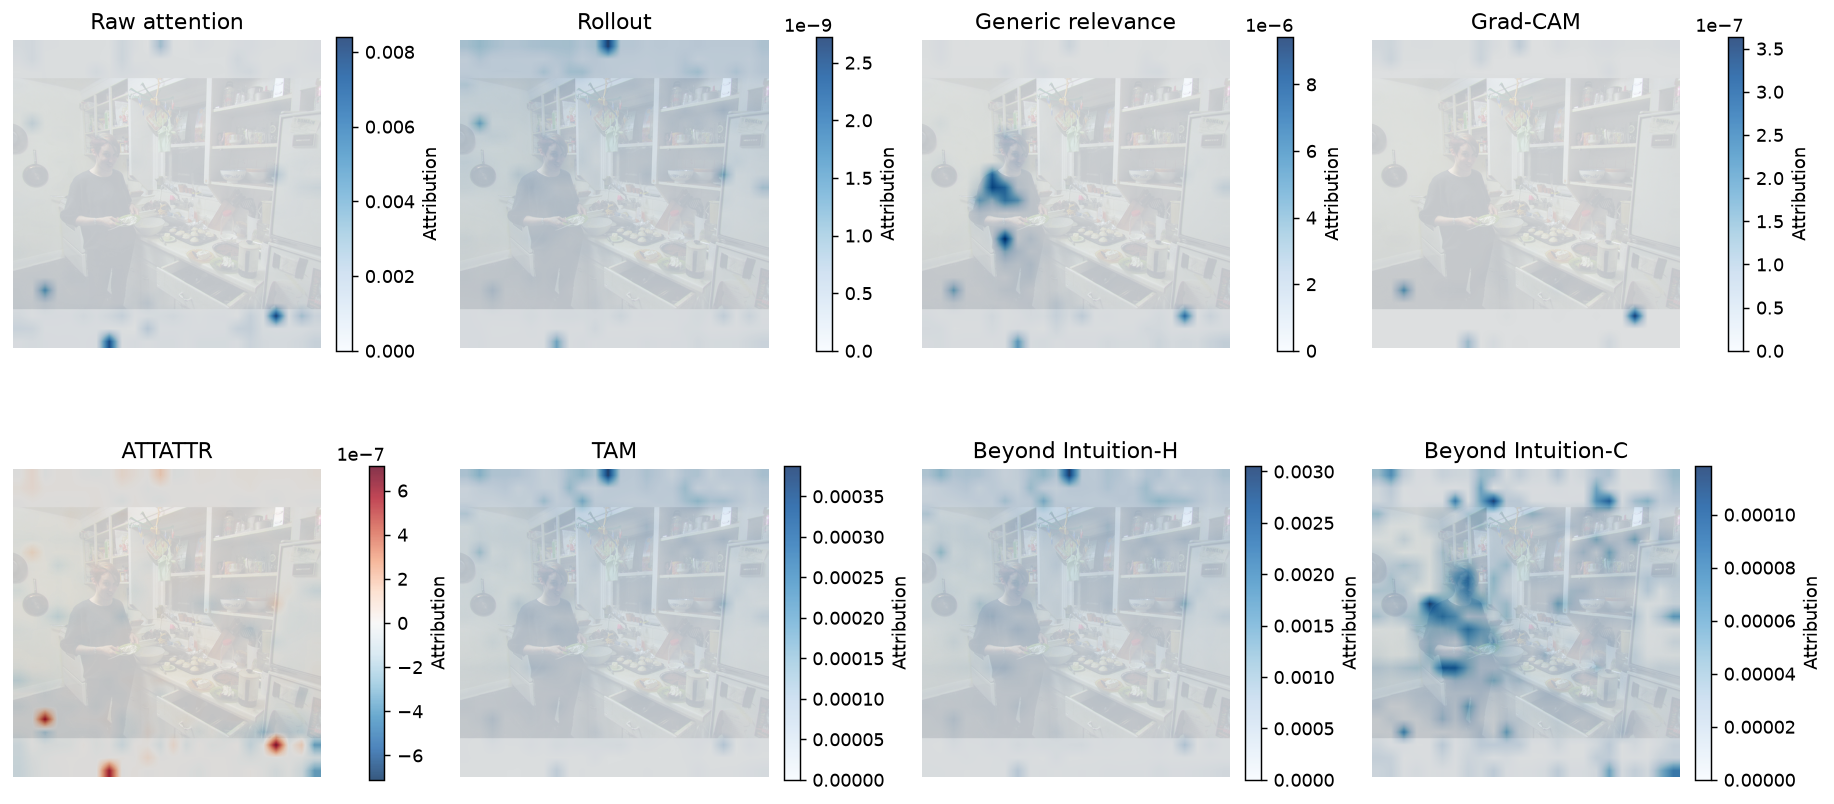

Native generated answer: Black
Fixed full-answer probability: 0.9982


In [2]:
records = [load_snapshot(f"vlm_attention_comparison/{sample}.json") for sample in ("07302654", "19225230")]
for record in records:
    image, box = gqa_input(record)
    ax = plot_input(load_image(record["sample"]["image_path"]), prompt=record["sample"]["question"],
                    answer=record["target_text"], bounding_boxes=[record["sample"]["bbox_xywh"]])
    show_figure(ax.figure)
    maps = {name: np.asarray(view["maps"])[-1] for name, view in record["methods"].items()}
    fig, axes = plot_attention_comparison(image, maps, grid_shape=(24,24), columns=4,
                                         signed={name:view["signed"] for name,view in record["methods"].items()}, alpha=.80)
    show_figure(fig)
    print("Native generated answer:", record["generated_answer"])
    print("Fixed full-answer probability:", round(record["answer"]["probability"], 4))

**How to read:** all maps overlay the actual square-padded model input, avoiding distortion from mapping a 24×24 token grid directly onto the original non-square photo. Target-conditioned maps use the sum of log probabilities of all answer pieces at teacher-forced prefixes. Positive and negative ATTATTR scores have a signed scale; unsigned methods describe positive relevance/attention. Each map is independently normalized for visibility. This comparison is a decoder-method transfer, not full vision-encoder attribution. Zero maps remain zero.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [3]:
if RERUN:
    from demos.runtime import bind_model, gqa_case, attention_methods
    from vlm_probing.metrics import SequenceLogProb
    probe, processor, device = bind_model("llava-hf/llava-1.5-7b-hf")
    base, scored, answer_mask, prediction_mask, masks, info = gqa_case(
        probe, processor, records[0]["sample"], ASSETS / "images")
    metric = SequenceLogProb(answer_mask)
    methods = attention_methods(probe, queries=prediction_mask, keys="visual", steps=20)
    results = {name: method.run(scored, metric=metric) for name,(method,_) in methods.items()}
    image, box = gqa_input(records[0])
    fig, axes = plot_attention_comparison(image, results, grid_shape=info["geometry"]["grid_shape"],
         visual_positions=np.flatnonzero(scored.layout.visual[0].cpu()),
         query_positions=np.flatnonzero(prediction_mask[0].cpu()), columns=4,
         signed={name:name=="ATTATTR" for name in results}, alpha=.80)
    show_figure(fig)
else:
    print("Fresh inference skipped.")

Fresh inference skipped.


## Sources and interpretation

**Data:** [GQA](https://cs.stanford.edu/people/dorarad/gqa/download.html), author [attribute-question subset](https://github.com/FightingFighting/cross-modal-information-flow-in-MLLM/tree/main/datasets), questions 07302654 and 19225230. **References:** same attention papers as [the ViT attention demo](attention_comparison_demo.ipynb). DTD/LRP is not available for this native VLM and is not replaced by a different rule.

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.